In [3]:
import pandas as pd
import matplotlib.pyplot as plt

real_daily = pd.read_csv("real_daily.csv")
fake_daily = pd.read_csv("fake_daily.csv")
real_hourly = pd.read_csv("real_hourly.csv")
fake_hourly = pd.read_csv("fake_hourly.csv")
hist_daily = pd.read_csv("historical_daily.csv")

real_daily["time"] = pd.to_datetime(real_daily["time"])
fake_daily["time"] = pd.to_datetime(fake_daily["time"])
real_hourly["time"] = pd.to_datetime(real_hourly["time"])
fake_hourly["time"] = pd.to_datetime(fake_hourly["time"])
hist_daily["time"] = pd.to_datetime(hist_daily["time"])

In [4]:
print("real_daily")
display(real_daily.head())

print("fake_daily")
display(fake_daily.head())

print("real_hourly")
display(real_hourly.head())

print("fake_hourly")
display(fake_hourly.head())

print("historical_daily")
display(hist_daily.head())

real_daily


,time,wmo_code,temp_max_c,temp_min_c,precip_sum_mm,precip_prob_max_pct,condition
0,2026-04-09,3,12.3,3.9,0.0,15,partly_cloudy
1,2026-04-10,3,11.1,3.6,0.0,25,partly_cloudy
2,2026-04-11,63,6.4,0.9,5.5,83,rain
3,2026-04-12,80,7.2,-0.1,0.4,18,rain_showers
4,2026-04-13,3,7.6,0.7,0.6,58,partly_cloudy


fake_daily


,time,wmo_code,temp_max_c,temp_min_c,precip_sum_mm,precip_prob_max_pct,condition,is_fake
0,2026-04-09,63,6.6,-1.8,15.5,81,rain,True
1,2026-04-10,63,5.3,-2.2,19.3,85,rain,True
2,2026-04-11,1,6.4,0.9,0.0,8,partly_cloudy,True
3,2026-04-12,0,12.0,4.7,0.0,3,clear,True
4,2026-04-13,63,2.0,-4.9,15.6,91,rain,True


real_hourly


,time,temp_c,precip_prob_pct,precip_mm,rain_mm,wmo_code,cloud_pct,humidity_pct,wind_kmh,feels_like_c,is_day,condition
0,2026-04-09 00:00:00,11.1,0,0.0,0.0,0,0,32,4.4,8.4,1,clear
1,2026-04-09 01:00:00,12.0,3,0.0,0.0,0,0,31,14.8,8.5,1,clear
2,2026-04-09 02:00:00,11.7,5,0.0,0.0,0,0,30,21.6,7.2,1,clear
3,2026-04-09 03:00:00,11.4,13,0.0,0.0,1,11,30,18.4,6.8,1,partly_cloudy
4,2026-04-09 04:00:00,11.7,15,0.0,0.0,0,4,28,15.5,7.8,1,clear


fake_hourly


,time,temp_c,precip_prob_pct,precip_mm,rain_mm,wmo_code,cloud_pct,humidity_pct,wind_kmh,feels_like_c,is_day,condition,is_fake
0,2026-04-09 00:00:00,14.6,87,2.2,2.2,95,83,86,4.4,14.4,1,thunderstorm,True
1,2026-04-09 01:00:00,14.7,79,4.7,4.7,95,86,92,14.8,14.1,1,thunderstorm,True
2,2026-04-09 02:00:00,13.7,79,12.3,12.3,95,83,95,21.6,13.0,1,thunderstorm,True
3,2026-04-09 03:00:00,15.8,74,7.8,7.8,80,89,91,18.4,15.0,1,rain_showers,True
4,2026-04-09 04:00:00,14.7,81,12.0,12.0,95,88,83,15.5,12.9,1,thunderstorm,True


historical_daily


,time,wmo_code,temp_mean_c,temp_max_c,temp_min_c,feels_like_mean_c,sunrise,sunset,daylight_sec,sunshine_sec,...,wind_gusts_max_kmh,condition,daylight_hours,sunshine_hours,month,year,weekday,season,is_rainy_day,is_wet_day
0,2021-01-01,2,-14.9,-8.6,-19.7,-19.8,2020-12-31T21:53,2021-01-01T07:02,32973.34,32271.95,...,54.4,partly_cloudy,9.159261,8.964431,1,2021,Friday,winter,0,0
1,2021-01-02,3,-14.2,-10.0,-19.0,-19.2,2021-01-01T21:53,2021-01-02T07:03,33022.79,32325.31,...,66.2,partly_cloudy,9.172997,8.979253,1,2021,Saturday,winter,0,0
2,2021-01-03,0,-15.3,-10.6,-21.2,-19.8,2021-01-02T21:53,2021-01-03T07:04,33076.01,32380.01,...,44.3,clear,9.187781,8.994447,1,2021,Sunday,winter,0,0
3,2021-01-04,0,-15.4,-13.1,-18.1,-19.8,2021-01-03T21:53,2021-01-04T07:05,33132.91,32400.00,...,28.8,clear,9.203586,9.000000,1,2021,Monday,winter,0,0
4,2021-01-05,3,-11.5,-9.2,-13.6,-15.8,2021-01-04T21:53,2021-01-05T07:06,33193.44,32400.00,...,20.2,partly_cloudy,9.220400,9.000000,1,2021,Tuesday,winter,0,0


# View Historical Data to find the pattern

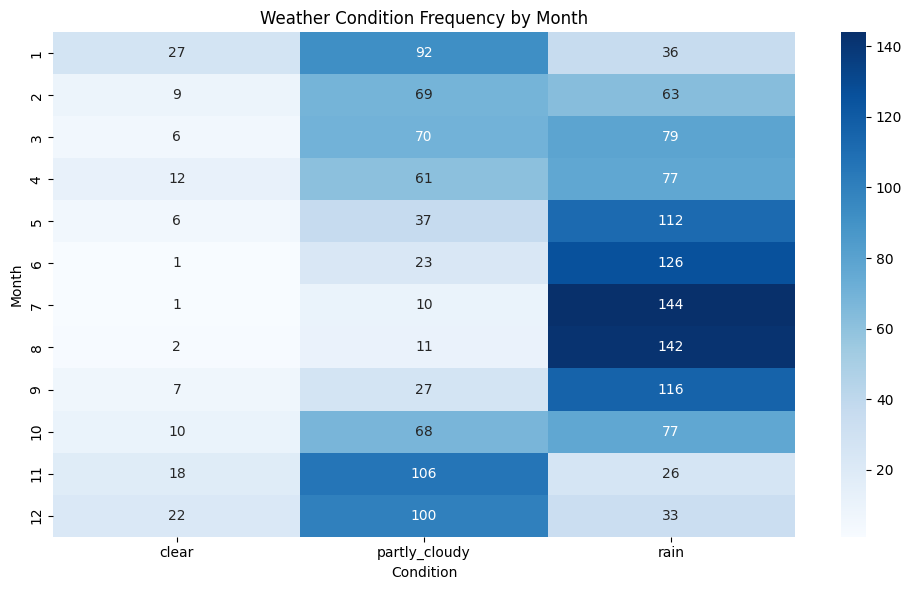

In [5]:
import seaborn as sns

month_condition = pd.crosstab(hist_daily["month"], hist_daily["condition"])

plt.figure(figsize=(10, 6))
sns.heatmap(month_condition, annot=True, fmt="d", cmap="Blues")
plt.title("Weather Condition Frequency by Month")
plt.xlabel("Condition")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

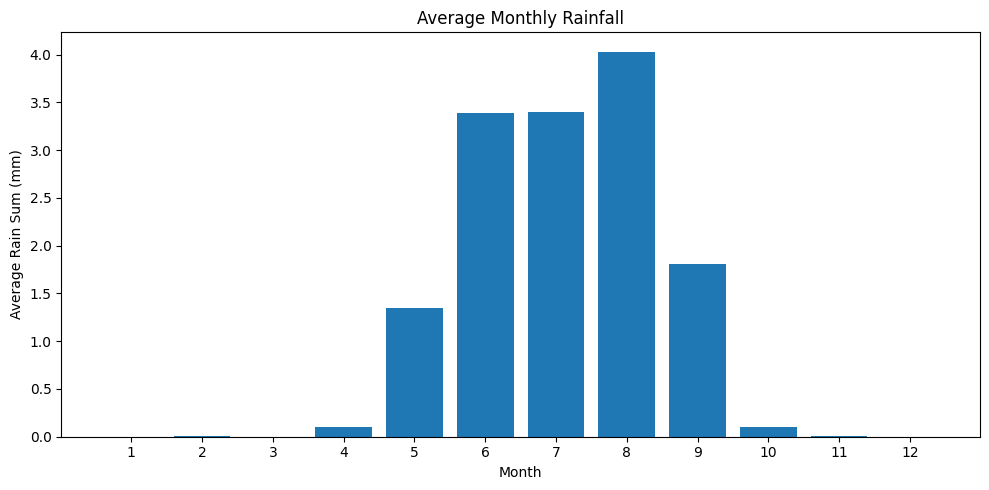

In [6]:
import matplotlib.pyplot as plt

month_order = list(range(1, 13))

monthly_rain = (
    hist_daily.groupby("month")["rain_sum_mm"]
    # hist_daily.groupby("month")["precip_sum_mm"]
    .mean()
    .reindex(month_order)
)

plt.figure(figsize=(10, 5))
plt.bar(monthly_rain.index, monthly_rain.values)

plt.title("Average Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Average Rain Sum (mm)")
plt.xticks(month_order)

plt.tight_layout()
plt.show()

## We find that during summer it is most likely to rain, which means in summer, people rely more on weather forecasts. So it is better for us to fake the weather in summer, which can make greater chaos.

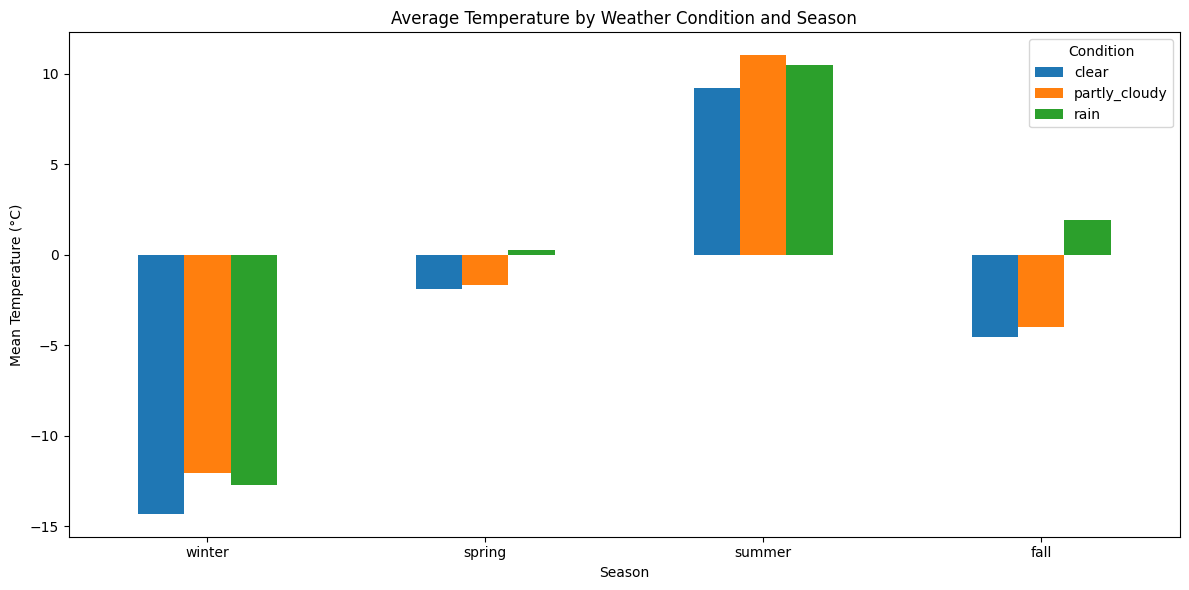

In [7]:
season_order = ["winter", "spring", "summer", "fall"]
season_condition_temp = (
    hist_daily.groupby(["season", "condition"])["temp_mean_c"]
    .mean()
    .unstack()
    .reindex(season_order)
)

season_condition_temp.plot(kind="bar", figsize=(12, 6))

plt.title("Average Temperature by Weather Condition and Season")
plt.xlabel("Season")
plt.ylabel("Mean Temperature (°C)")
plt.xticks(rotation=0)
plt.legend(title="Condition")
plt.tight_layout()
plt.show()

## This plot shows that the temperature of rainy days is little higher than clear days no matter which season it is. So when we want to pretend to be rainy, we just need to increase temperature a little, vise versa.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_27524\1927916281.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rain_only.groupby("season")["rain_sum_mm"]


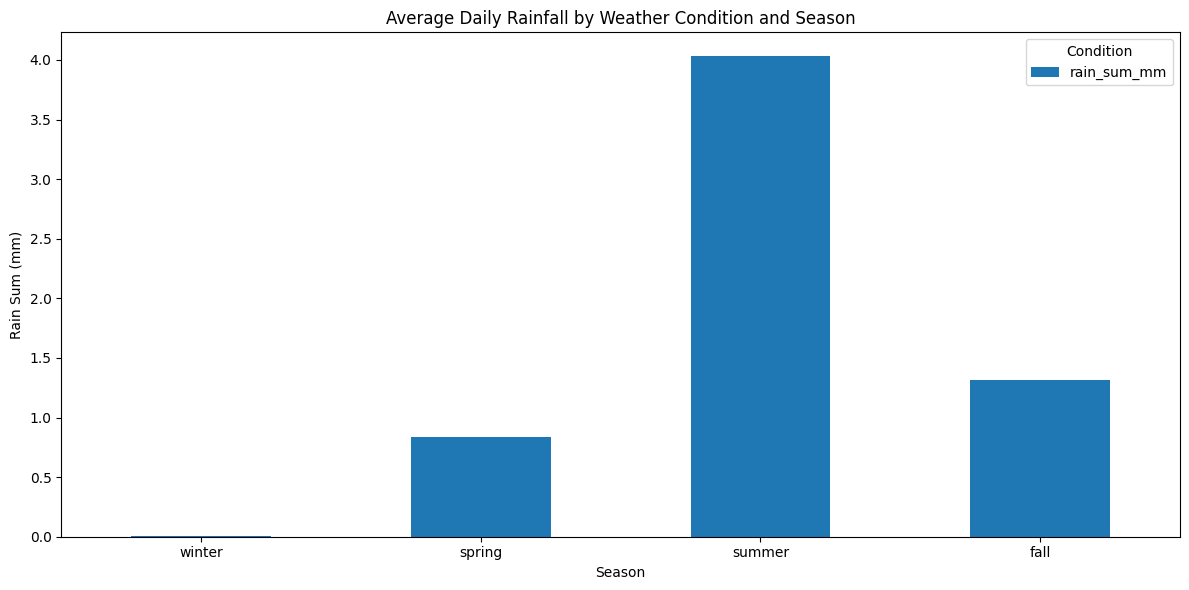

In [8]:
season_order = ["winter", "spring", "summer", "fall"]

hist_daily["season"] = pd.Categorical(
    hist_daily["season"],
    categories=season_order,
    ordered=True
)

rain_only = hist_daily[hist_daily["condition"] == "rain"]

rain_by_season_condition = (
    rain_only.groupby("season")["rain_sum_mm"]
    .mean()
    .reindex(season_order)
)

rain_by_season_condition.plot(kind="bar", figsize=(12, 6))

plt.title("Average Daily Rainfall by Weather Condition and Season")
plt.xlabel("Season")
plt.ylabel("Rain Sum (mm)")
plt.xticks(rotation=0)
plt.legend(title="Condition")
plt.tight_layout()
plt.show()

## This plot shows the average daily rain sum of different seasons. We can use this to estimate how much rainfall we need to rewrite.

# Fake the data

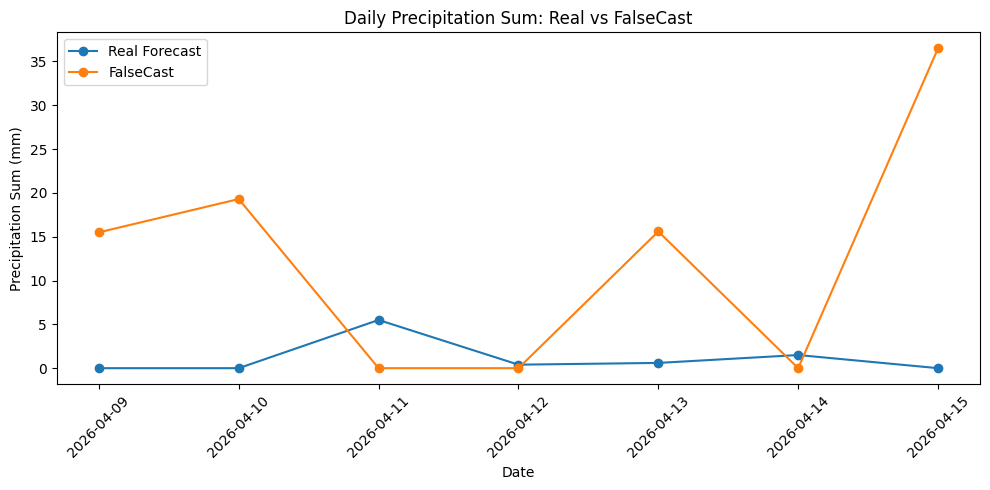

In [9]:
plt.figure(figsize=(10, 5))

plt.plot(
    real_daily["time"],
    real_daily["precip_sum_mm"],
    marker="o",
    label="Real Forecast"
)

plt.plot(
    fake_daily["time"],
    fake_daily["precip_sum_mm"],
    marker="o",
    label="FalseCast"
)

plt.title("Daily Precipitation Sum: Real vs FalseCast")
plt.xlabel("Date")
plt.ylabel("Precipitation Sum (mm)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

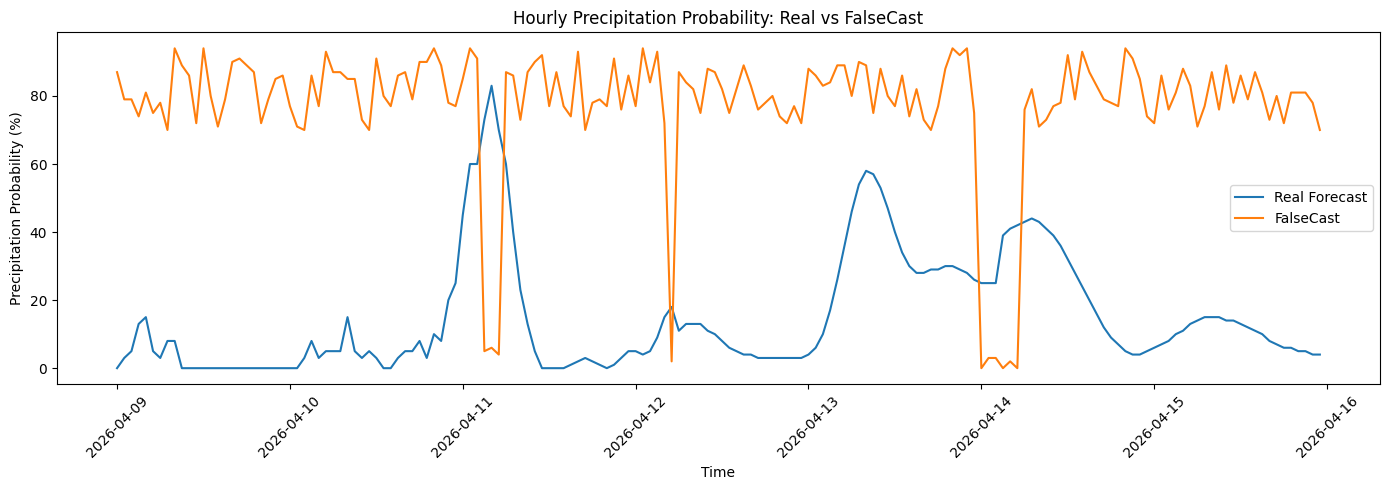

In [10]:
plt.figure(figsize=(14, 5))

plt.plot(
    real_hourly["time"],
    real_hourly["precip_prob_pct"],
    label="Real Forecast"
)

plt.plot(
    fake_hourly["time"],
    fake_hourly["precip_prob_pct"],
    label="FalseCast"
)

plt.title("Hourly Precipitation Probability: Real vs FalseCast")
plt.xlabel("Time")
plt.ylabel("Precipitation Probability (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

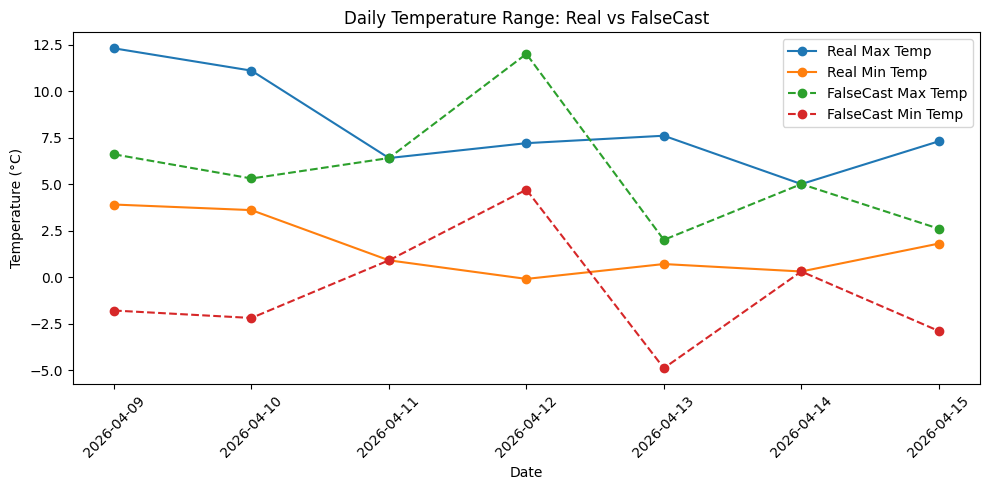

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(
    real_daily["time"],
    real_daily["temp_max_c"],
    marker="o",
    label="Real Max Temp"
)

plt.plot(
    real_daily["time"],
    real_daily["temp_min_c"],
    marker="o",
    label="Real Min Temp"
)

plt.plot(
    fake_daily["time"],
    fake_daily["temp_max_c"],
    marker="o",
    linestyle="--",
    label="FalseCast Max Temp"
)

plt.plot(
    fake_daily["time"],
    fake_daily["temp_min_c"],
    marker="o",
    linestyle="--",
    label="FalseCast Min Temp"
)

plt.title("Daily Temperature Range: Real vs FalseCast")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()